Analyse de la variable cible

In [4]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("C:/Users/fredm/Desktop/projet_IA/besoin_client_4/data/export_IA.csv")

print("Nombre de valeurs manquantes :")
print(df["puissance_nominale"].isnull().sum())

print("\nStatistiques descriptives :")
print(df["puissance_nominale"].describe())

print("\nNombre de valeurs différentes :")
print(df["puissance_nominale"].nunique())

print("\n20 puissances les plus fréquentes :")
print(df["puissance_nominale"].value_counts().head(20))

Nombre de valeurs manquantes :
0

Statistiques descriptives :
count    182496.000000
mean         70.771591
std          92.956418
min           0.000100
25%          22.000000
50%          22.000000
75%         100.000000
max         400.000000
Name: puissance_nominale, dtype: float64

Nombre de valeurs différentes :
181

20 puissances les plus fréquentes :
puissance_nominale
22.00     71495
7.40      13025
7.00      12326
150.00    10581
50.00      9649
300.00     9607
250.00     6982
22.08      6313
100.00     4290
120.00     3533
24.00      3111
200.00     3073
18.00      3005
180.00     2495
3.70       2485
7.36       1742
25.00      1326
400.00     1231
350.00     1209
60.00      1194
Name: count, dtype: int64


C:\Users\fredm\AppData\Local\Temp\ipykernel_4276\3496080012.py:4: DtypeWarning: Columns (6,10,11,12,13,14,16,19,22) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("C:/Users/fredm/Desktop/projet_IA/besoin_client_4/data/export_IA.csv")


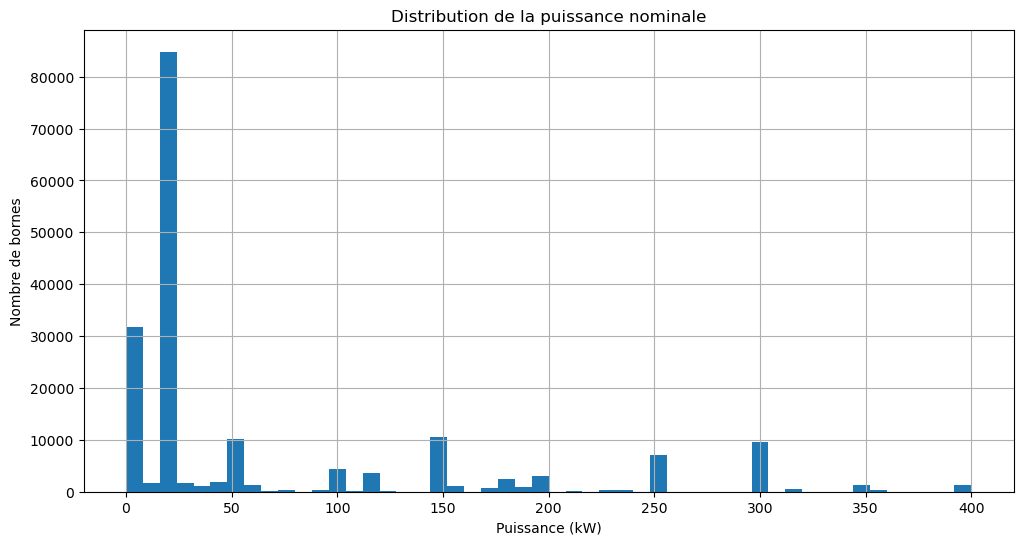

In [5]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

df["puissance_nominale"].hist(
    bins=50
)

plt.title("Distribution de la puissance nominale")
plt.xlabel("Puissance (kW)")
plt.ylabel("Nombre de bornes")

plt.show()

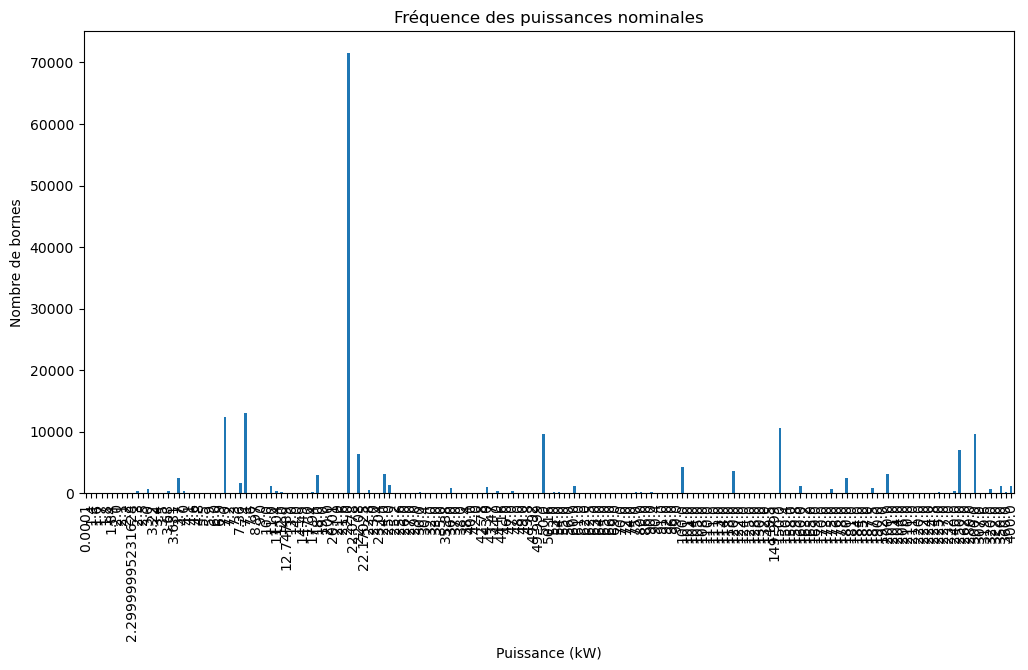

In [6]:
plt.figure(figsize=(12,6))

df["puissance_nominale"].value_counts()\
    .sort_index()\
    .plot(kind="bar")

plt.title("Fréquence des puissances nominales")
plt.xlabel("Puissance (kW)")
plt.ylabel("Nombre de bornes")

plt.show()

Changé les données textes en données exploitables

In [7]:
bool_cols = [
    "prise_type_ef",
    "prise_type_2",
    "prise_type_combo_ccs",
    "prise_type_chademo",
    "prise_type_autre",
    "gratuit",
    "paiement_acte",
    "reservation",
    "accessibilite_pmr",
    "station_deux_roues"
]

def convert_bool(x):

    if pd.isna(x):
        return 0

    x = str(x).strip().lower()

    if x in ["true", "1", "oui", "yes"]:
        return 1

    return 0

for col in bool_cols:
    df[col] = df[col].apply(convert_bool)

In [8]:
print(df[bool_cols].dtypes)

prise_type_ef           int64
prise_type_2            int64
prise_type_combo_ccs    int64
prise_type_chademo      int64
prise_type_autre        int64
gratuit                 int64
paiement_acte           int64
reservation             int64
accessibilite_pmr       int64
station_deux_roues      int64
dtype: object


In [9]:
colonnes = [
    "nbre_pdc",
    "prise_type_ef",
    "prise_type_2",
    "prise_type_combo_ccs",
    "prise_type_chademo",
    "prise_type_autre",
    "gratuit",
    "paiement_acte",
    "reservation",
    "accessibilite_pmr",
    "station_deux_roues",
    "annee_mise_en_service",
    "puissance_nominale"
]

corr = df[colonnes].corr()

print(
    corr["puissance_nominale"]
    .sort_values(ascending=False)
)

puissance_nominale       1.000000
prise_type_combo_ccs     0.748908
paiement_acte            0.132045
station_deux_roues       0.071159
annee_mise_en_service    0.021702
gratuit                 -0.008195
prise_type_chademo      -0.011509
prise_type_autre        -0.057308
nbre_pdc                -0.080368
reservation             -0.148342
prise_type_ef           -0.371649
prise_type_2            -0.666494
accessibilite_pmr             NaN
Name: puissance_nominale, dtype: float64


Importation des modèle de régression

In [10]:
#   Séparation train/test
from sklearn.model_selection import train_test_split

#   Régression Linéaire
from sklearn.linear_model import LinearRegression

#   Random Forest Regressor
from sklearn.ensemble import RandomForestRegressor

#   Gradient Boosting Regressor
from sklearn.ensemble import GradientBoostingRegressor

In [11]:
features = [
    "nbre_pdc",
    "prise_type_ef",
    "prise_type_2",
    "prise_type_combo_ccs",
    "prise_type_chademo",
    "prise_type_autre",
    "gratuit",
    "paiement_acte",
    "reservation",
    "accessibilite_pmr",
    "station_deux_roues",
    "annee_mise_en_service",
    "implantation_station",
    "consolidated_latitude",
    "consolidated_longitude"
]

target = "puissance_nominale"

df_ml = df[features + [target]].copy()

In [36]:
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()

df_ml["implantation_station"] = (
    encoder.fit_transform(
        df_ml["implantation_station"]
    )
)

import joblib

joblib.dump(
    encoder,
    "encoder_implantation.pkl"
)

print("Encodeur sauvegardé avec succès.")

Encodeur sauvegardé avec succès.


In [14]:
df_ml = df_ml.dropna()

In [15]:
from sklearn.model_selection import train_test_split

X = df_ml[features]
y = df_ml[target]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

Régression Linéaire

In [16]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()

lr.fit(X_train, y_train)

pred_lr = lr.predict(X_test)

Fonction d'évaluation

In [17]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

def evaluate(y_true, y_pred, model_name):

    mae = mean_absolute_error(y_true, y_pred)

    rmse = mean_squared_error(
        y_true,
        y_pred
    ) ** 0.5

    r2 = r2_score(
        y_true,
        y_pred
    )

    print("\n", model_name)
    print("MAE :", round(mae,2))
    print("RMSE :", round(rmse,2))
    print("R² :", round(r2,4))

In [18]:
evaluate(
    y_test,
    pred_lr,
    "Linear Regression"
)


 Linear Regression
MAE : 46.51
RMSE : 65.45
R² : 0.5891


Random Forest

In [19]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

pred_rf = rf.predict(X_test)

In [20]:
evaluate(
    y_test,
    pred_rf,
    "Random Forest"
)


 Random Forest
MAE : 9.72
RMSE : 29.61
R² : 0.9159


Gradient Boosting

In [21]:
from sklearn.ensemble import GradientBoostingRegressor

gb = GradientBoostingRegressor(
    random_state=42
)

gb.fit(X_train, y_train)

pred_gb = gb.predict(X_test)

evaluate(
    y_test,
    pred_gb,
    "Gradient Boosting"
)


 Gradient Boosting
MAE : 31.56
RMSE : 50.01
R² : 0.76


GridSearchCV

Optimisons le Random Forest

In [23]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestRegressor

param_grid = {
    "n_estimators": [50, 100],
    "max_depth": [10, None]
}

grid = GridSearchCV(
    RandomForestRegressor(
        random_state=42,
        n_jobs=1
    ),
    param_grid=param_grid,
    cv=3,
    scoring="r2",
    n_jobs=1,
    verbose=2
)

grid.fit(X_train, y_train)

Fitting 3 folds for each of 4 candidates, totalling 12 fits
[CV] END ......................max_depth=10, n_estimators=50; total time=   3.8s
[CV] END ......................max_depth=10, n_estimators=50; total time=   4.9s
[CV] END ......................max_depth=10, n_estimators=50; total time=   5.3s
[CV] END .....................max_depth=10, n_estimators=100; total time=  10.3s
[CV] END .....................max_depth=10, n_estimators=100; total time=  11.3s
[CV] END .....................max_depth=10, n_estimators=100; total time=  10.5s
[CV] END ....................max_depth=None, n_estimators=50; total time=   8.2s
[CV] END ....................max_depth=None, n_estimators=50; total time=   9.1s
[CV] END ....................max_depth=None, n_estimators=50; total time=   7.9s
[CV] END ...................max_depth=None, n_estimators=100; total time=  16.6s
[CV] END ...................max_depth=None, n_estimators=100; total time=  16.7s
[CV] END ...................max_depth=None, n_est

GridSearchCV(cv=3, estimator=RandomForestRegressor(n_jobs=1, random_state=42),
             n_jobs=1,
             param_grid={'max_depth': [10, None], 'n_estimators': [50, 100]},
             scoring='r2', verbose=2)

Récupérerons le meilleur modèle

In [24]:
print(grid.best_params_)
print(grid.best_score_)

{'max_depth': None, 'n_estimators': 100}
0.9048419680310941


In [25]:
best_model = grid.best_estimator_

Évaluons le modèle optimisé

In [26]:
pred_best = best_model.predict(X_test)

evaluate(
    y_test,
    pred_best,
    "Random Forest Optimisé"
)


 Random Forest Optimisé
MAE : 9.72
RMSE : 29.61
R² : 0.9159


In [27]:
import pandas as pd
import matplotlib.pyplot as plt

importance = pd.DataFrame({
    "Variable": X.columns,
    "Importance": best_model.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

print(importance)

                  Variable  Importance
3     prise_type_combo_ccs    0.566626
12    implantation_station    0.143426
0                 nbre_pdc    0.099634
13   consolidated_latitude    0.057951
14  consolidated_longitude    0.053864
11   annee_mise_en_service    0.027225
2             prise_type_2    0.011778
4       prise_type_chademo    0.011671
1            prise_type_ef    0.008390
7            paiement_acte    0.006707
8              reservation    0.005422
10      station_deux_roues    0.005263
5         prise_type_autre    0.001876
6                  gratuit    0.000168
9        accessibilite_pmr    0.000000


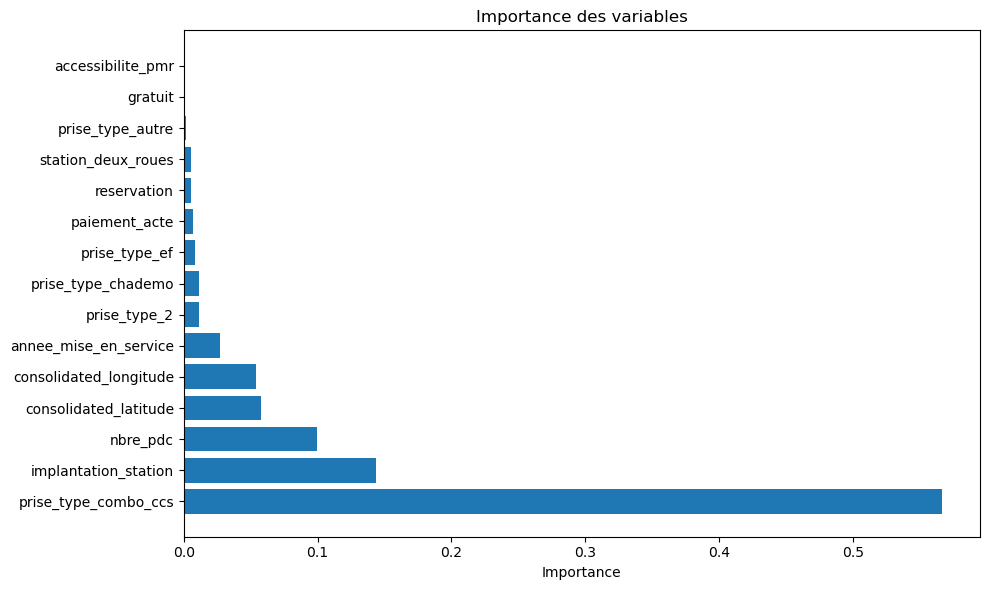

In [28]:
plt.figure(figsize=(10,6))

plt.barh(
    importance["Variable"],
    importance["Importance"]
)

plt.title("Importance des variables")
plt.xlabel("Importance")

plt.tight_layout()
plt.show()

Les variables les plus influentes dans la prédiction de la puissance nominale sont les prises_type_combo_ccs

Graphique réel vs prédiction

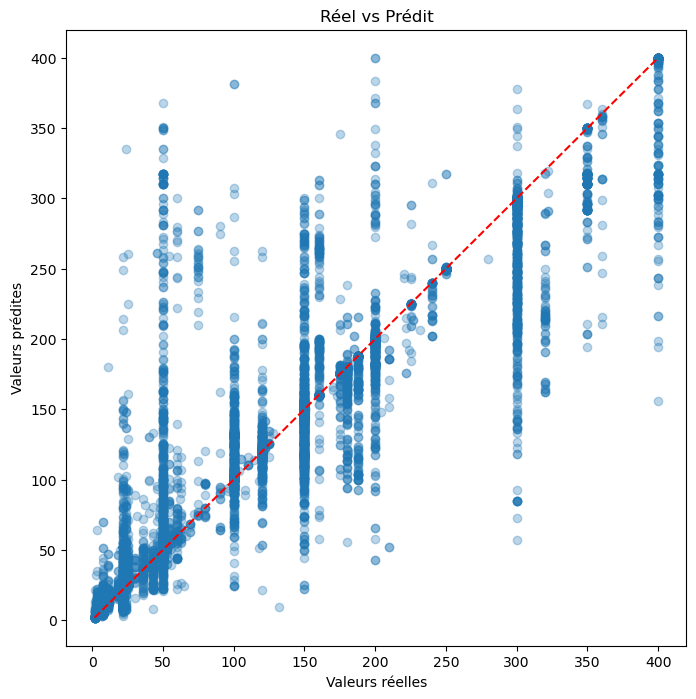

In [29]:
plt.figure(figsize=(8,8))

plt.scatter(
    y_test,
    pred_best,
    alpha=0.3
)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'r--'
)

plt.xlabel("Valeurs réelles")
plt.ylabel("Valeurs prédites")

plt.title("Réel vs Prédit")

plt.show()

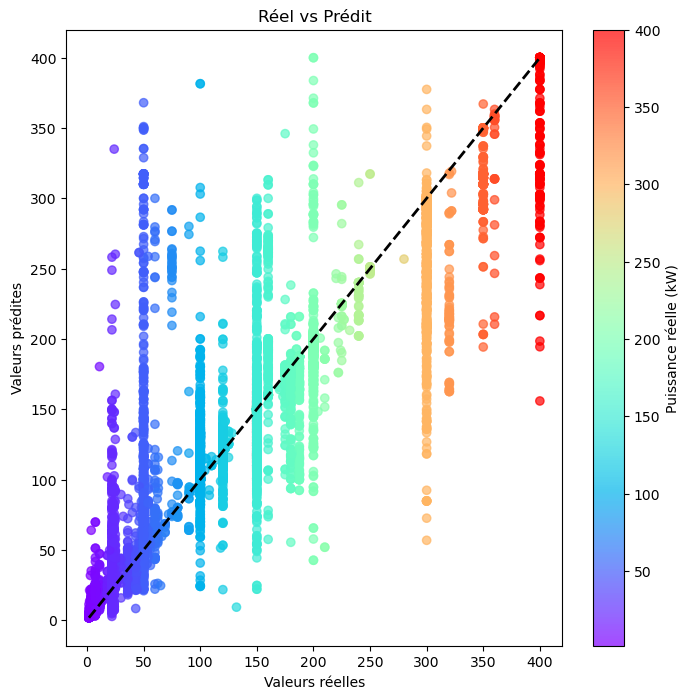

In [30]:
plt.figure(figsize=(8,8))

scatter = plt.scatter(
    y_test,
    pred_best,
    c=y_test,          # couleur selon la valeur réelle
    cmap="rainbow",
    alpha=0.7
)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'k--',
    linewidth=2
)

plt.colorbar(scatter, label="Puissance réelle (kW)")

plt.xlabel("Valeurs réelles")
plt.ylabel("Valeurs prédites")
plt.title("Réel vs Prédit")

plt.show()

Analyse des Érreurs

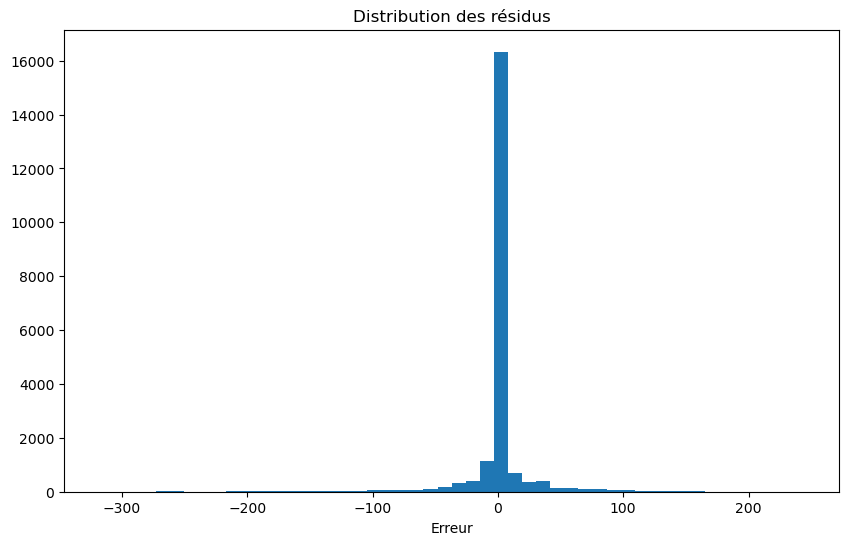

In [32]:
residus = y_test - pred_best

plt.figure(figsize=(10,6))

plt.hist(
    residus,
    bins=50
)

plt.title("Distribution des résidus")
plt.xlabel("Erreur")

plt.show()

Sauvegarde du modèle

In [33]:
import joblib

joblib.dump(
    best_model,
    "modele_puissance.pkl"
)

['modele_puissance.pkl']

Vérification

In [34]:
model_loaded = joblib.load(
    "modele_puissance.pkl"
)

Script de prédiction